# 01 · EDA y Predicción de RUL — Vibración de Rodamientos (NASA/IMS)

Análisis exploratorio de la señal de vibración real (NASA IMS Bearing Dataset, 3 experimentos
run-to-failure) y comparación de modelos para predecir vida útil restante.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from src.ingest import EXPERIMENTS, SAMPLING_RATE_HZ
from scipy.fft import rfft, rfftfreq

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


## 1. La señal cruda: una lectura real de acelerómetro

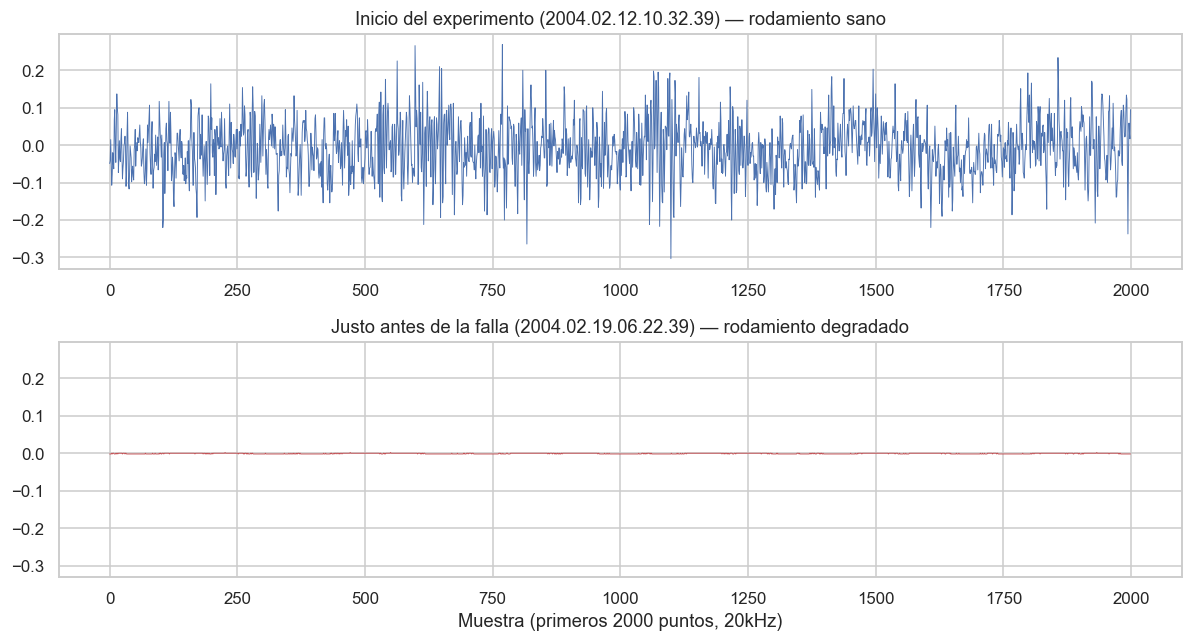

In [2]:
folder = EXPERIMENTS["2nd_test"]
files = sorted(folder.iterdir(), key=lambda p: p.name)
early_file, late_file = files[0], files[-1]

early_signal = np.loadtxt(early_file)[:, 0]
late_signal = np.loadtxt(late_file)[:, 0]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharey=True)
axes[0].plot(early_signal[:2000], color="#4C72B0", linewidth=0.6)
axes[0].set_title(f"Inicio del experimento ({early_file.name}) — rodamiento sano")
axes[1].plot(late_signal[:2000], color="#C44E52", linewidth=0.6)
axes[1].set_title(f"Justo antes de la falla ({late_file.name}) — rodamiento degradado")
axes[1].set_xlabel("Muestra (primeros 2000 puntos, 20kHz)")
plt.tight_layout()
plt.savefig("outputs/reports/raw_signal_early_vs_late.png", dpi=150)
plt.show()


## 2. Espectro de frecuencia: la falla deja huella en el dominio de Fourier

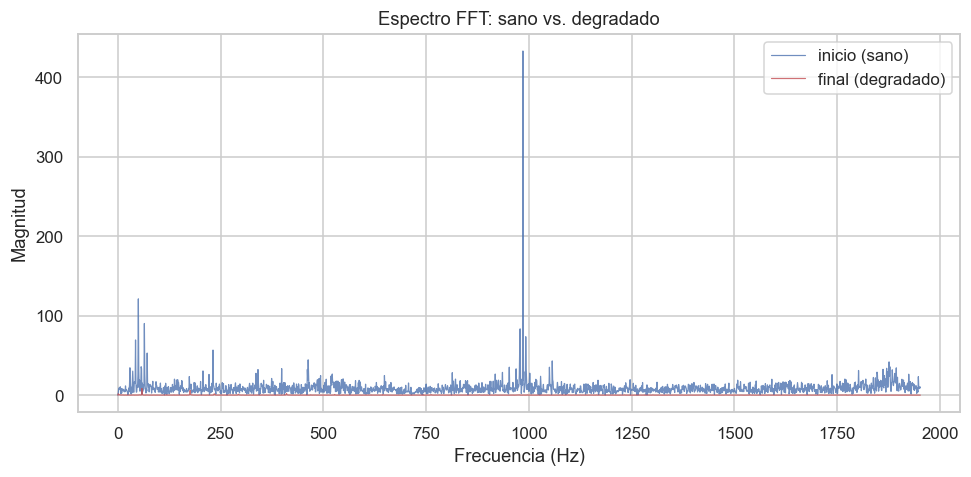

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for signal, label, color in [(early_signal, "inicio (sano)", "#4C72B0"), (late_signal, "final (degradado)", "#C44E52")]:
    fft_mag = np.abs(rfft(signal - signal.mean()))
    freqs = rfftfreq(len(signal), d=1.0 / SAMPLING_RATE_HZ)
    ax.plot(freqs[:2000], fft_mag[:2000], label=label, color=color, alpha=0.8, linewidth=0.8)
ax.set_title("Espectro FFT: sano vs. degradado")
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Magnitud")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/reports/fft_spectrum_comparison.png", dpi=150)
plt.show()


## 3. Curva de degradación real: RMS creciendo a lo largo de todo el experimento

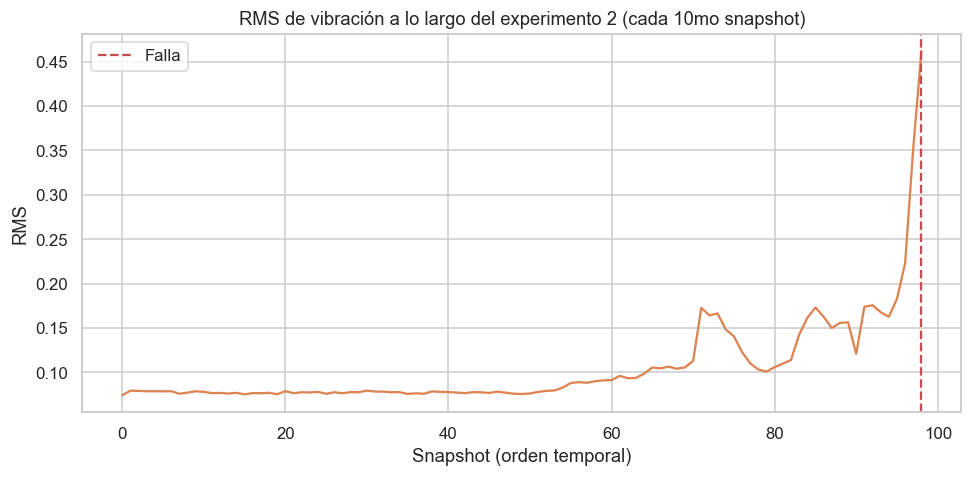

In [4]:
rms_trend = []
for f in files[::10]:
    sig = np.loadtxt(f)[:, 0]
    rms_trend.append(np.sqrt(np.mean(sig**2)))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rms_trend, color="#DD8452")
ax.set_title("RMS de vibración a lo largo del experimento 2 (cada 10mo snapshot)")
ax.set_xlabel("Snapshot (orden temporal)")
ax.set_ylabel("RMS")
ax.axvline(len(rms_trend) - 1, color="#C44E52", linestyle="--", label="Falla")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/reports/rms_degradation_curve.png", dpi=150)
plt.show()


## 4. El bug real: minutos absolutos vs. RUL fraccional

In [5]:
metrics = pd.read_csv("outputs/reports/model_metrics.csv")
metrics


,target,model,mae_mean,mae_std
0,minutes_absolute,random_forest,14775.985399,8679.856576
1,minutes_absolute,lightgbm,15665.150842,9279.747448
2,minutes_absolute,catboost,17553.102878,9595.570175
3,minutes_absolute,ridge,20976.151903,5937.920738
4,minutes_absolute,lasso,27265.740657,15957.691341
5,rul_fraction,catboost,0.215883,0.019801
6,rul_fraction,lasso,0.240318,0.071634
7,rul_fraction,lightgbm,0.242807,0.018104
8,rul_fraction,random_forest,0.254551,0.053160
9,rul_fraction,ridge,0.299917,0.089451


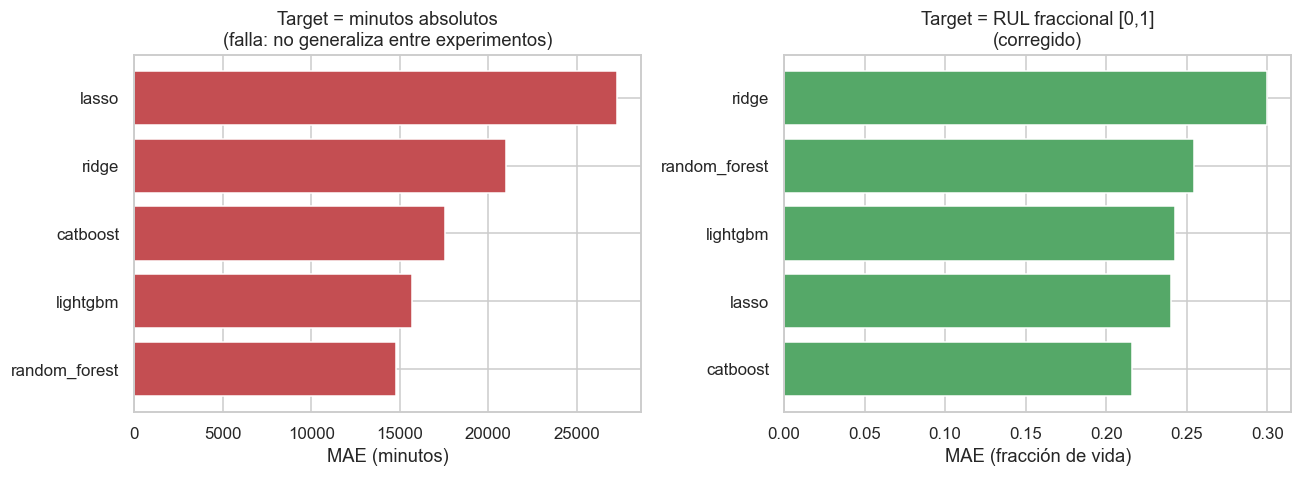

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

minutes = metrics[metrics["target"] == "minutes_absolute"].sort_values("mae_mean")
axes[0].barh(minutes["model"], minutes["mae_mean"], color="#C44E52")
axes[0].set_title("Target = minutos absolutos\n(falla: no generaliza entre experimentos)")
axes[0].set_xlabel("MAE (minutos)")

frac = metrics[metrics["target"] == "rul_fraction"].sort_values("mae_mean")
axes[1].barh(frac["model"], frac["mae_mean"], color="#55A868")
axes[1].set_title("Target = RUL fraccional [0,1]\n(corregido)")
axes[1].set_xlabel("MAE (fracción de vida)")

plt.tight_layout()
plt.savefig("outputs/reports/target_fix_comparison.png", dpi=150)
plt.show()


## 5. Conclusión

- La señal muestra degradación visible tanto en el dominio temporal (RMS creciente) como en el
  espectral (energía en nuevas bandas de frecuencia cerca de la falla).
- Bug real encontrado y corregido: predecir minutos absolutos no generaliza entre los 3 experimentos
  (duran entre 7 y 44 días) — el RUL fraccional [0,1] es la solución estándar, y CatBoost
  logra MAE=0.216 (21.6% de la vida restante) en GroupKFold leave-one-experiment-out.